In [2]:
# solver for Yukawa potential
# central field potential - use radial schrodinger eqn

In [3]:
# ========================
# Import Packages/Modules
# ========================
import matplotlib.pyplot as plt  # from hydrogen.py
import numpy as np  # from hydrogen.py
from jwanglibs import rootfinder as rtf  # from hydrogen.py
import matplotlib.cm as cm  # for colormap plots
from scipy.integrate import trapezoid  # wf normalization

In [4]:
#For now, we will be using 1.0 for our constants for easy calculation and visualization.

In [ ]:
# ========================
# Define Functions
# ========================
def V(r):  # Yukawa Potential
    '''
    Yukawa piecewise potential:
        Spherical well inside interaction range a (depth varied by V0)
        Exponential decay outside well (interaction strength varied by lamda)

    Another method:
        if r <=a:
            return -V0
        else:
            return np.exp(-lamda*r)/r
        Then -> V_vec = np.vectorize(V) to allow for vectorized plotting
    '''
    return np.where(r <= a, -V0, np.exp(-lamda*r)/r)

def centrifugal(r):  # Centrifugal Potential
    '''
    Centrifugal potential:
    L = orbital angular momentum quantum number
    Disappears for 1s states (L=0)
    '''
    return hbar**2*L*(L+1)/(2*m*r**2)

def V_eff(r):  # Effective Potential
    '''
    from hydrogen.py
    return L*(L+1)/(2*m*r**2) - 1/(4*pi*)/r  # centrifugal + coulomb
    '''
    return centrifugal(r) + V(r)  # centrifugal + yukawa

def f(r):  # Sch eqn in Numerov form
    return 2*m*(E-V_eff(r))/hbar**2  # rearrange radial Sch eqn

def numerov(f, u, n, x, h):  # Numerov function
    '''
    Numerov integrator for $u''+f(x)u=0$
    '''
    nodes, c = 0, h**2/12.  # given $[u_0,u_1]$, return $[u_0,u_1,...,u_{n+1}]$
    f0, f1 = f(x), f(x+h)
    for i in range(n):
        x += h
        f2 = f(x+h)  # Numerov method below
        u.append((2*(1-5*c*f1)*u[i+1] - (1+c*f0)*u[i])/(1+c*f2))  # Numerov update
        f0, f1 = f1, f2
        if u[-1]*u[-2] < 0.0:
            nodes += 1
    return u, nodes  # return u, nodes

def shoot(En):  # Shooting function
    global E  # E needed in f(r)
    E, c, xm = En, (h**2)/6., xL + M*h
    wfup, nup = numerov(f, [0,.1], M, xL, h)  # outward integration from left
    wfdn, ndn = numerov(f, [0,.1], N-M, xR, -h)  # inward integration from right
    dup = ((1+c*f(xm+h))*wfup[-1] - (1+c*f(xm-h))*wfup[-3])/(h+h)
    ddn = ((1+c*f(xm+h))*wfdn[-3] - (1+c*f(xm-h))*wfdn[-1])/(h+h)
    return dup*wfdn[-2] - wfup[-2]*ddn

In [ ]:
# ===================
# Initial Conditions
# ===================
xL, N = 10e-6, 3000  # limits, interval
xR, V0, a, lamda = 25.0, 20.0, 2.0, 0.2  # variables to test convergence (xR=right limit, V0=well depth, a=well width, lamda=screening strength)
hbar, m = 1.0, 1.0  # constants
h = (xR-xL)/N  # step size
Lmax, EL = 6, []  # define max L, blank L array
M = int(a*N/xR)  # M = matching point

In [13]:
# ================================================
# Calculate energy for n, l, and associated nodes
# ================================================
Estart, dE = -V0-0.1, 0.001  # scan from well bottom -V0
list_psix = [[] for _ in range(Lmax)]  # store wfs for each L and n
#list_n = []

for L in range(Lmax):  # pure bound states (E < 0)
    n, E1, Ea = L+1, Estart, []
    while (E1 < -4*dE):  # sweep E range for each L for pure bound states (E < 0)
    #while (E1 < np.exp(-lamda*a)/a + hbar**2*L*(L+1)/(2*m*a**2)):  # sweep E range for each L until upper well bound
        E1 += dE
        if (shoot(E1)*shoot(E1 + dE) > 0):
            continue
        E = rtf.bisect(shoot, E1, E1 + dE, 1.e-8)
        Ea.append(E)  # append E value to energy array Ea
        wfup, nup = numerov(f, [0,.1], M-1, xL, h)  # calc wf
        wfdn, ndn = numerov(f, [0,.1], N-M-1, xR, -h)
        psix = np.concatenate((wfup[:-1], wfdn[::-1]))
        psix[M:] *= wfup[-1]/wfdn[-1]  # match
        list_psix[L].append(psix)
        #list_n.append(n)
        
        print ('nodes = %i, n = %i,l = %i, E = %.8e' %(nup+ndn, n, L, E))
        n += 1
    EL.append(Ea)

nodes = 0, n = 1,l = 0, E = -1.89365378e+01
nodes = 1, n = 2,l = 0, E = -1.57644070e+01
nodes = 2, n = 3,l = 0, E = -1.05551715e+01
nodes = 3, n = 4,l = 0, E = -3.55421042e+00
nodes = 0, n = 2,l = 1, E = -1.78269335e+01
nodes = 1, n = 3,l = 1, E = -1.36163037e+01
nodes = 2, n = 4,l = 1, E = -7.44242895e+00
nodes = 0, n = 3,l = 2, E = -1.64295365e+01
nodes = 1, n = 4,l = 2, E = -1.11829131e+01
nodes = 2, n = 5,l = 2, E = -4.10906306e+00
nodes = 0, n = 4,l = 3, E = -1.47588576e+01
nodes = 1, n = 5,l = 3, E = -8.48162306e+00
nodes = 2, n = 6,l = 3, E = -6.57187795e-01
nodes = 0, n = 5,l = 4, E = -1.28252572e+01
nodes = 1, n = 6,l = 4, E = -5.53241055e+00
nodes = 0, n = 6,l = 5, E = -1.06370960e+01
nodes = 1, n = 7,l = 5, E = -2.36309119e+00


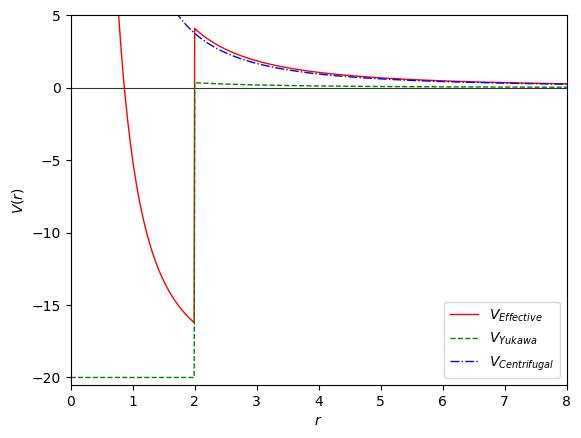

In [14]:
# plot potential
r = np.linspace(xL, xR, N)  # r range

plt.figure()
plt.axhline(0, color='k', ls='-', lw=0.8, alpha=0.8)  # dashed x-axis
plt.plot(r, V_eff(r), 'r-', lw=1.0, label='$V_{Effective}$')
plt.plot(r, V(r), 'g--', lw=1.0, label='$V_{Yukawa}$')
plt.plot(r, centrifugal(r), 'b-.', lw=1.0, label='$V_{Centrifugal}$')
plt.xlim(0, 8)
plt.ylim(-V0-0.5, 5)
plt.xlabel('$r$')
plt.ylabel('$V(r)$')
plt.legend()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_52166/2672408429.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$'), plt.ylabel('$E$')
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_52166/2672408429.py:33: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$'), plt.ylabel('$E$')


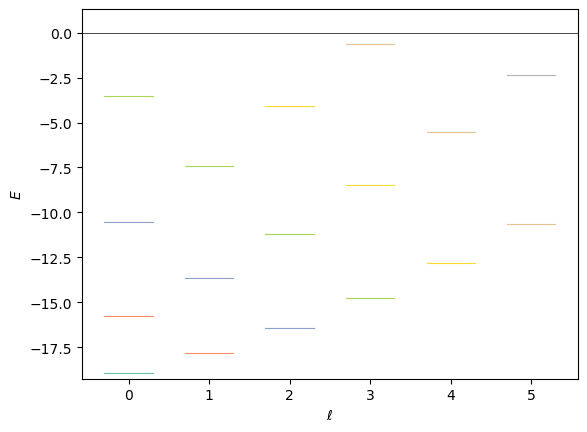

In [ ]:
# =========
# Plotting
# =========
# Some code for plotting added with help of Claude

# Create a colormap for different n-values
max_n = max(len(EL[L]) for L in range(Lmax))  # Find max number of n-values
colors = cm.Set2(np.linspace(0, 1, Lmax + 1))  # extend colormap for all possible n
#colors = cm.hsv(np.linspace(0, 1, Lmax + max_n))  # extend colormap for all possible n

legend = set()  # track which n values have been added to legend

plt.figure()  # plot energy levels
for L in range(Lmax):
    for i in range(len(EL[L])):
        list_n = L+i+1  # quantum number n
        label = f'$n$ = {list_n}' if list_n not in legend else None
        plt.plot([L-.3, L+.3], [EL[L][i]]*2, color=colors[L+i], lw=0.8, label=label, alpha=1.0)
        legend.add(list_n)  # append n value to prevent duplicate legend entries

plt.axhline(0, color='k', ls='-', lw=0.5, alpha=1.0)
plt.xlabel('$\ell$'), plt.ylabel('$E$')
plt.ylim(EL[0][0]-.3, 1.3), plt.xticks(range(Lmax))
#plt.ylim(EL[0][0]-.3, EL[-1][-1]+.3), plt.xticks(range(Lmax))
#plt.legend(title='$n$ values', loc='upper center')
plt.show()

[0.00000000e+00 1.17003843e-02 2.33990404e-02 ... 2.00456468e-63
 1.33345397e-63 6.65851163e-64]


<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_52166/785038290.py:18: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Reduced Radial Wave Function: $n={L+i+1}$, $\ell = {L}$')


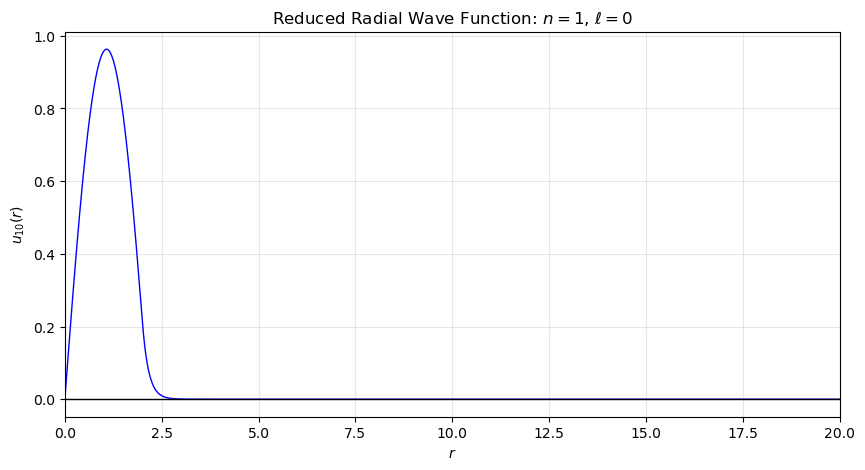

[ 0.00000000e+00  2.32669948e-02  4.65203028e-02 ... -8.74210874e-58
 -5.81745826e-58 -2.90554765e-58]


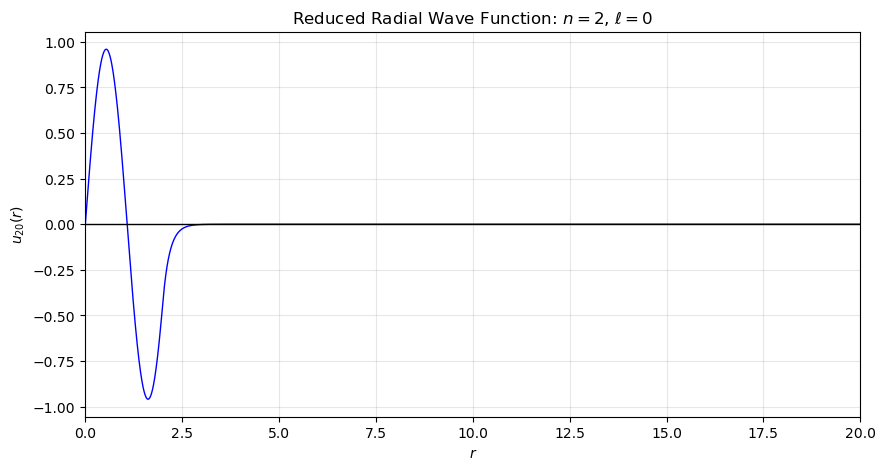

[0.00000000e+00 3.44382513e-02 6.88313322e-02 ... 1.61573079e-47
 1.07583955e-47 5.37525711e-48]


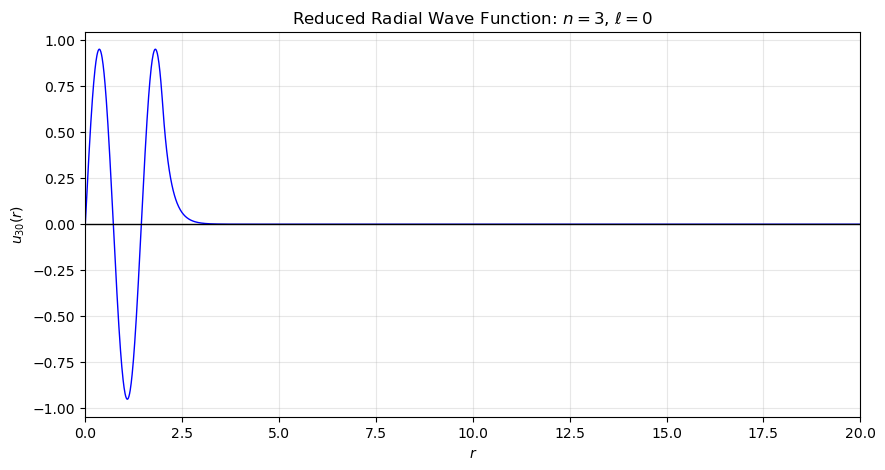

[ 0.00000000e+00  4.39992696e-02  8.78980580e-02 ... -2.00743988e-28
 -1.33774291e-28 -6.68706386e-29]


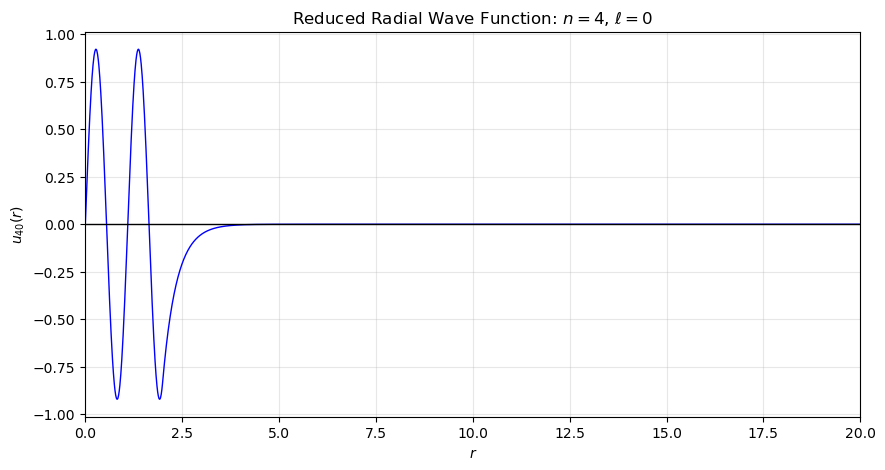

[0.00000000e+00 1.04506816e-04 3.99358021e-04 ... 1.73277904e-61
 1.15280728e-61 5.75690726e-62]


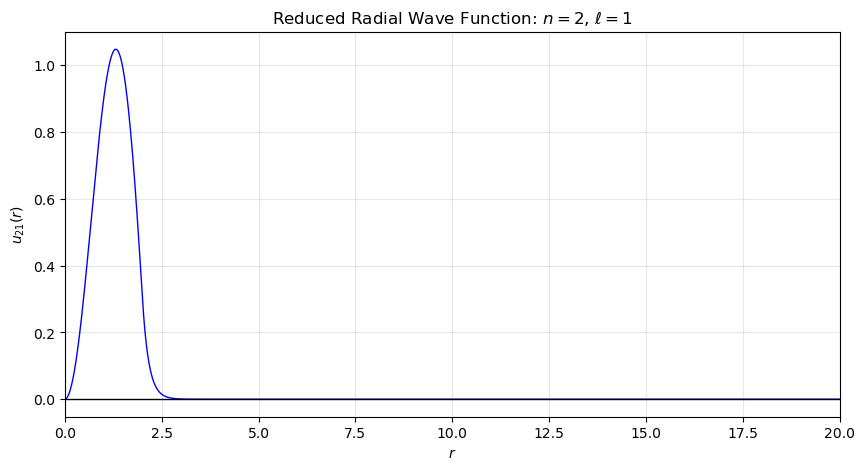

[ 0.00000000e+00  3.00553822e-04  1.14831272e-03 ... -8.30526271e-54
 -5.52812877e-54 -2.76145245e-54]


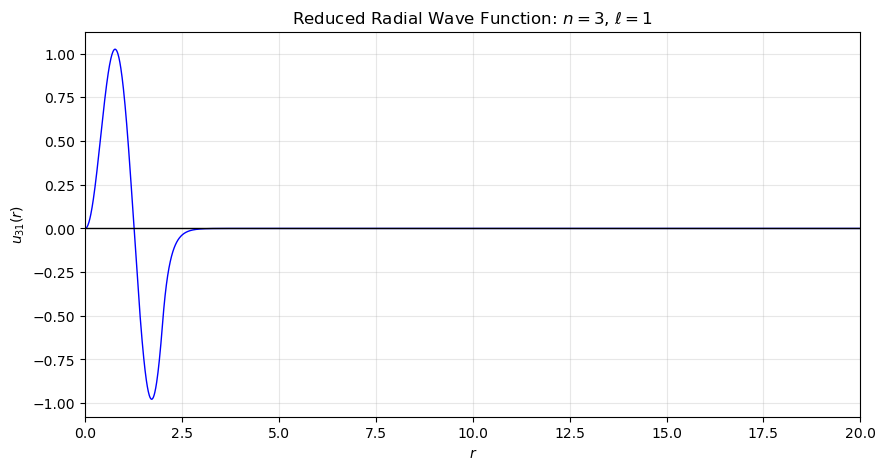

[0.00000000e+00 5.80410227e-04 2.21694972e-03 ... 3.08515465e-40
 2.05499919e-40 1.02696864e-40]


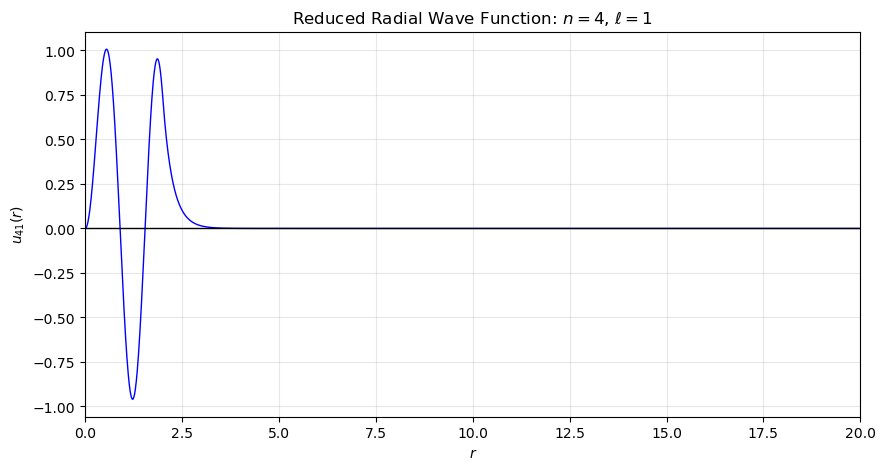

[0.00000000e+00 7.43793727e-07 5.93851868e-06 ... 4.41138257e-59
 2.93533846e-59 1.46599578e-59]


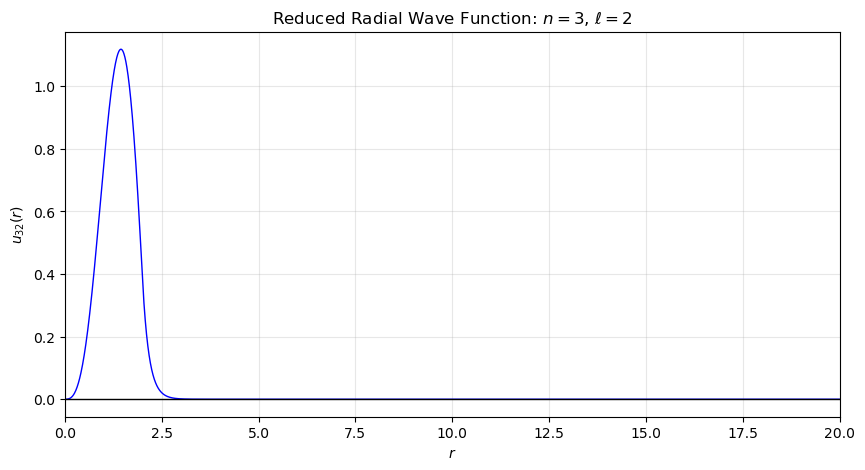

[ 0.00000000e+00  2.78320046e-06  2.22178601e-05 ... -5.55197272e-49
 -3.69652862e-49 -1.84682924e-49]


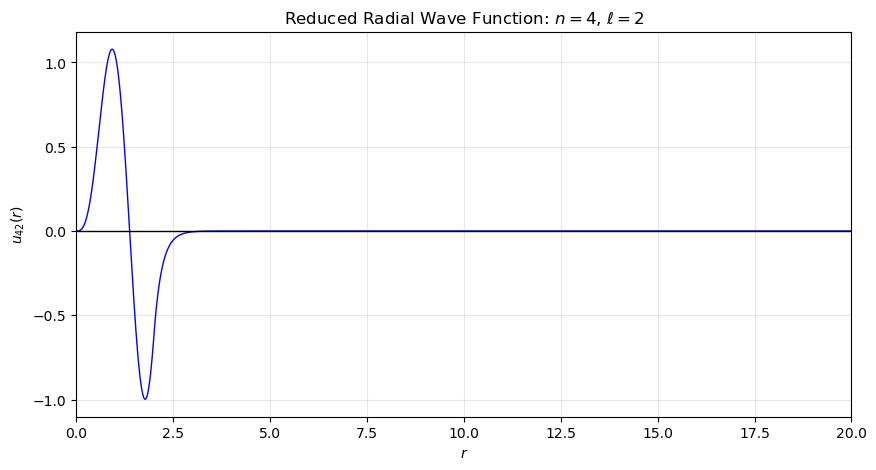

[0.00000000e+00 6.50651041e-06 5.19295253e-05 ... 1.39909447e-30
 9.32285722e-31 4.66009714e-31]


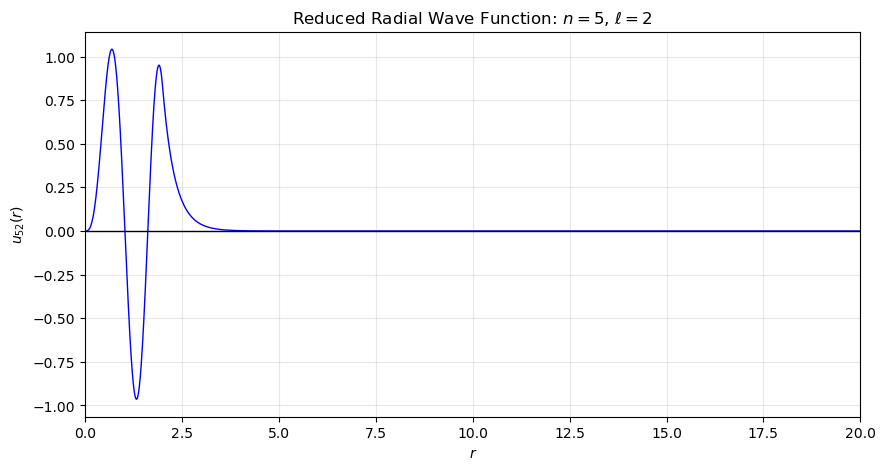

[0.00000000e+00 5.19943151e-09 8.29807418e-08 ... 3.81986129e-56
 2.54222880e-56 1.26981185e-56]


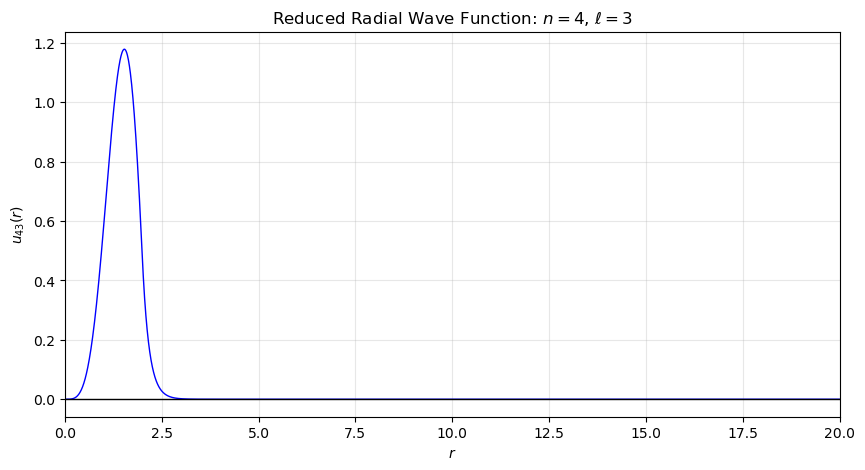

[ 0.00000000e+00  2.38910035e-08  3.81230331e-07 ... -4.80644519e-43
 -3.20115073e-43 -1.59963199e-43]


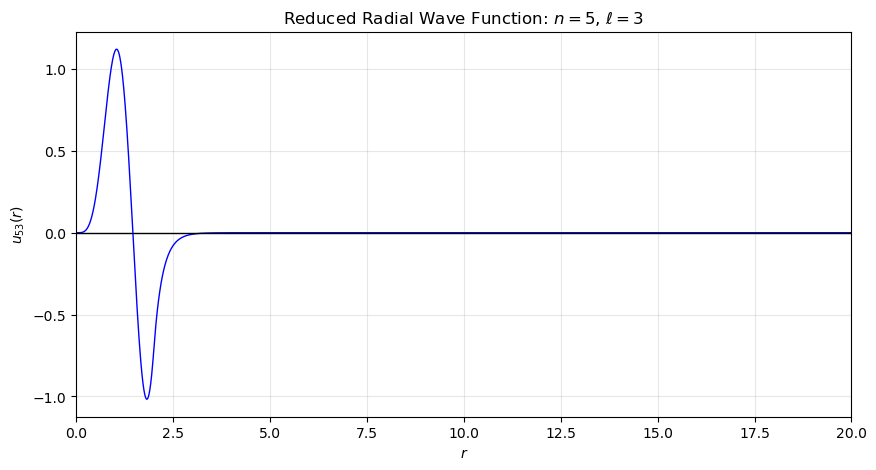

[0.00000000e+00 6.23956255e-08 9.95455717e-07 ... 1.83886837e-14
 1.22581761e-14 6.12880412e-15]


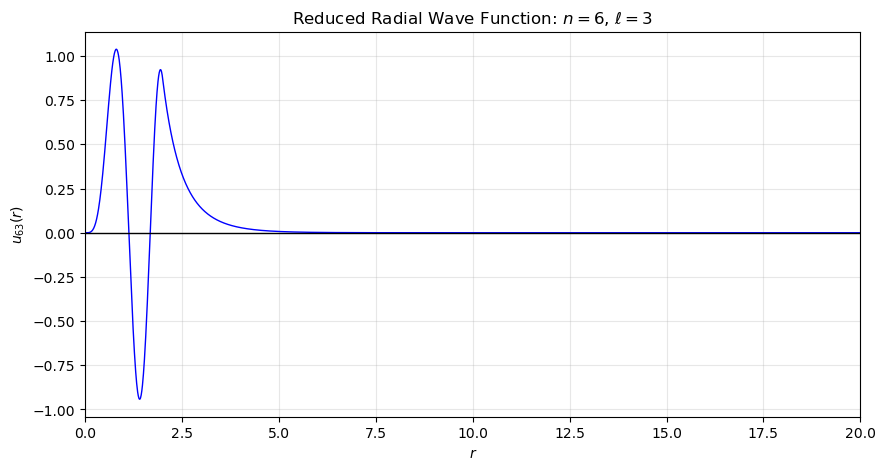

[0.00000000e+00 3.47604911e-11 1.10879955e-09 ... 1.36487954e-52
 9.08569338e-53 4.53879851e-53]


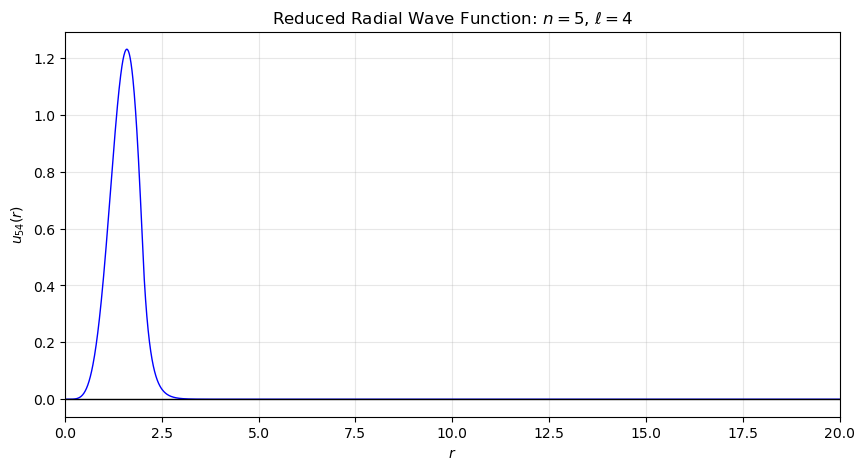

[ 0.00000000e+00  1.88379433e-10  6.00783733e-09 ... -1.84595886e-35
 -1.22984943e-35 -6.14687843e-36]


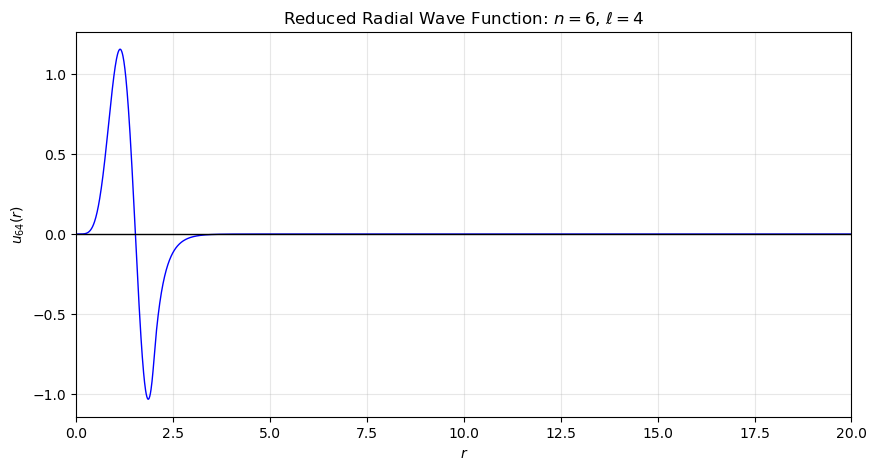

[0.00000000e+00 1.98765276e-13 1.42461965e-11 ... 2.72033490e-48
 1.81132156e-48 9.04990669e-49]


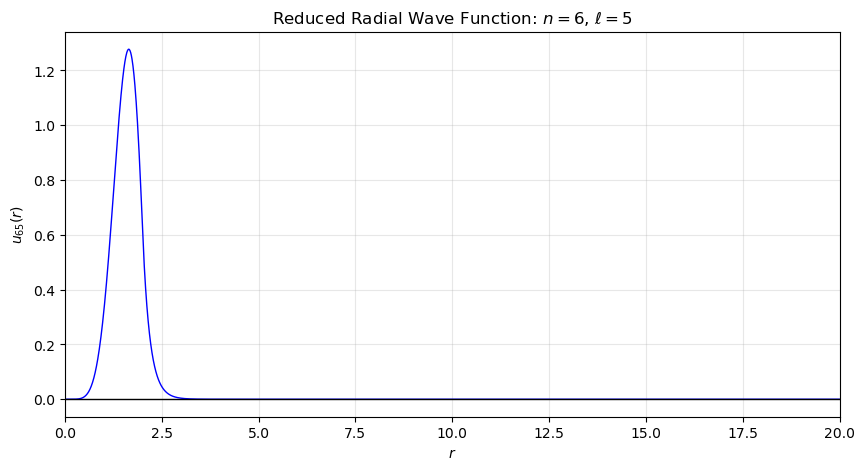

[ 0.00000000e+00  1.22636289e-12  8.78721673e-11 ... -1.00752804e-24
 -6.71499816e-25 -3.35694252e-25]


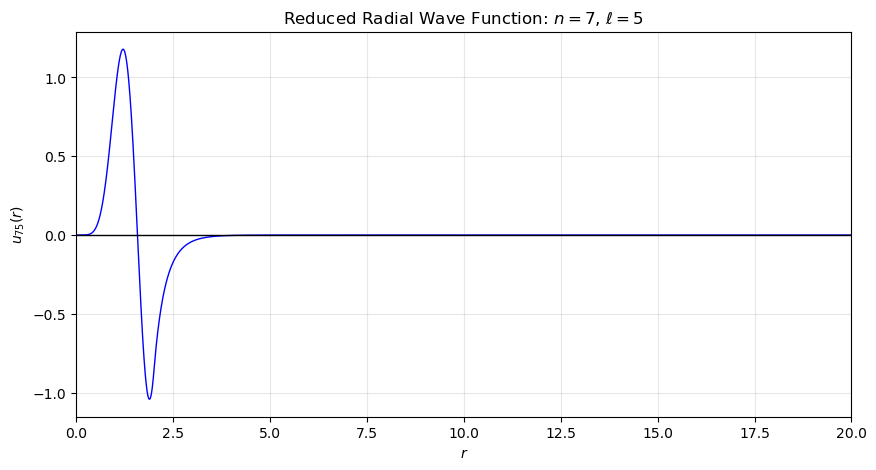

In [19]:
# plot normalized reduced radial wave functions for all L and n values
for L in range(Lmax):
    for i, psi in enumerate(list_psix[L]):
        psi_truncated = psi[:len(r)]
        norm = np.sqrt(trapezoid(abs(psi_truncated)**2, r)) # normalize
        psi_normalized = psi_truncated / norm
        print(psi_normalized)

        prob_density = abs(psi_normalized)**2

        plt.figure(figsize=(10, 5))
        plt.plot(r, psi_normalized, lw=1.0, color='b')
        #plt.plot(r, prob_density, lw=1.5, color='orange', label='Probability Density')  # Add probability density plot
        #plt.plot(r, V_eff(r), 'r--', alpha=0.5)
        plt.axhline(0, color='k', ls='-', lw=1.0, alpha=1.0)
        plt.xlabel('$r$')
        plt.ylabel(f'$u_{{{L+i+1}{L}}}(r)$')
        plt.title(f'Reduced Radial Wave Function: $n={L+i+1}$, $\ell = {L}$')
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 20)  # Focus on region near potential well
        #plt.ylim(-22, 5)
        #plt.tight_layout()
        plt.show()